In [ ]:
using_colab = True

if using_colab:
    import sys
    !git clone https://github.com/facebookresearch/sam3.git /content/sam3
    %cd /content/sam3
    !{sys.executable} -m pip install -e ".[notebooks]"
    !{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir \
        "numpy==2.2.6" \
        "scipy==1.15.3" \
        "scikit-image==0.25.2" \
        "scikit-learn==1.7.2" \
        "pillow==11.3.0" \
        opencv-python matplotlib

fatal: destination path '/content/sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp313-cp313-linux_x86_64.whl
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.14.0.94-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.13.0.90-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x

In [ ]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

In [ ]:
import torch

# turn on tfloat32 for Ampere GPUs
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [ ]:
bpe_path = os.path.join(
    os.path.dirname(sam3.__file__),
    "assets",
    "bpe_simple_vocab_16e6.txt.gz",
)
model = build_sam3_image_model(bpe_path=bpe_path)

In [ ]:
image_path = "/content/lat_-2.0_long_-16.0_original.png"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

found 1 object(s)


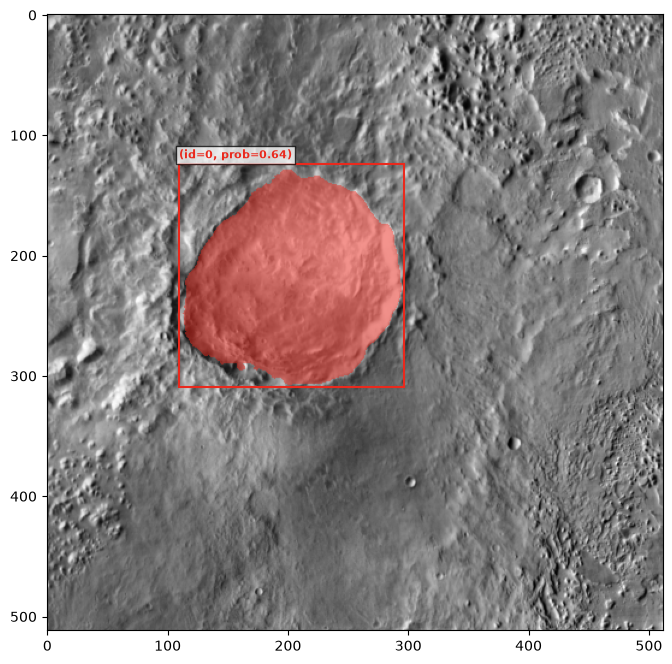

In [ ]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(
    state=inference_state,
    prompt="crater",
)

img0 = Image.open(image_path)
plot_results(img0, inference_state)

found 5 object(s)


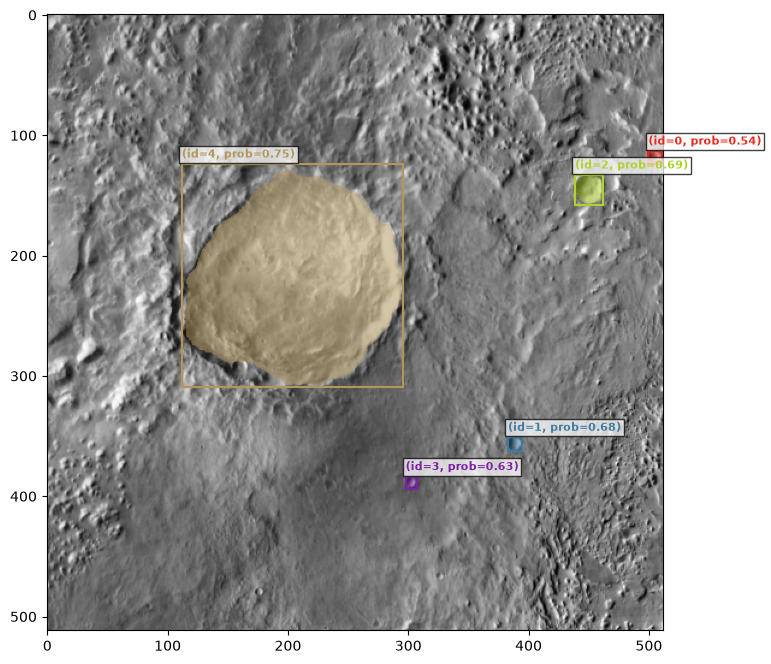

In [ ]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(
    state=inference_state,
    prompt="circle",
)

img0 = Image.open(image_path)
plot_results(img0, inference_state)